In [1]:
import pandas as pd
import os
import re
import matplotlib.pyplot as plt
import numpy as np
import pickle

In [2]:
def group_data(dir_path: str):
    # Load the results
    files_to_read = [file for file in os.listdir(dir_path) if file.endswith('.csv')]
    pattern = r'agent_stats_run_(\d+)_ctr_(\d+\.?\d*)_alpha_(\d+\.?\d*)'
    results = pd.DataFrame()
    for file in files_to_read:
        match = re.search(pattern, file)
        if match:
            soglia_ctr = float(match.group(2))
            alpha = float(match.group(3))
            
            curr_results = pd.read_csv(dir_path + file)

            curr_results['soglia_ctr'] = soglia_ctr
            curr_results['alpha'] = alpha

            results = pd.concat([results, curr_results])
    # Prima raggruppo per Run e Iteration per avere il dato aggregato per ogni iterazione
    grouped_results_run_iter = results.groupby(['soglia_ctr','alpha', 'Run', 'Iteration']) \
        .agg({'clicks': 'sum', 'impressions': 'sum', 'true_clicks': 'sum', 'est_clicks': 'sum', 'est_impressions': 'sum', 'publisher':'nunique'}) \
        .reset_index()
    grouped_results_run_iter['ctr'] = grouped_results_run_iter['clicks'] / grouped_results_run_iter['impressions']
    grouped_results_run_iter['true_ctr'] = grouped_results_run_iter['true_clicks'] / grouped_results_run_iter['impressions']
    # Valori medi sulle run per ogni iterazione
    grouped_results = grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).mean().reset_index()
    # intervallo di confidenza click
    grouped_results['clicks_std'] = grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).std().reset_index()['clicks']
    grouped_results['clicks_ci'] = 1.96 * grouped_results['clicks_std'] / np.sqrt(grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).count().reset_index()['clicks'])
    # intervallo di confidenza true_clicks
    grouped_results['true_clicks_std'] = grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).std().reset_index()['true_clicks']
    grouped_results['true_clicks_ci'] = 1.96 * grouped_results['true_clicks_std'] / np.sqrt(grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).count().reset_index()['true_clicks'])
    # intervallo di confidenza impressions
    grouped_results['impressions_std'] = grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).std().reset_index()['impressions']
    grouped_results['impressions_ci'] = 1.96 * grouped_results['impressions_std'] / np.sqrt(grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).count().reset_index()['impressions'])
    # intervallo di confidenza CTR e True CTR
    grouped_results['ctr_std'] = grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).std().reset_index()['ctr']
    grouped_results['ctr_ci'] = 1.96 * grouped_results['ctr_std'] / np.sqrt(grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).count().reset_index()['ctr'])
    grouped_results['true_ctr_std'] = grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).std().reset_index()['true_ctr']
    grouped_results['true_ctr_ci'] = 1.96 * grouped_results['true_ctr_std'] / np.sqrt(grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).count().reset_index()['true_ctr'])
    # estimated clicks
    grouped_results['est_clicks_std'] = grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).std().reset_index()['est_clicks']
    grouped_results['est_clicks_ci'] = 1.96 * grouped_results['est_clicks_std'] / np.sqrt(grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).count().reset_index()['est_clicks'])
    # estimated impressions
    grouped_results['est_impressions_std'] = grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).std().reset_index()['est_impressions']
    grouped_results['est_impressions_ci'] = 1.96 * grouped_results['est_impressions_std'] / np.sqrt(grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).count().reset_index()['est_impressions'])
    # publisher
    grouped_results['publisher_std'] = grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).std().reset_index()['publisher']
    grouped_results['publisher_ci'] = 1.96 * grouped_results['publisher_std'] / np.sqrt(grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).count().reset_index()['publisher'])
    return grouped_results

In [3]:
def group_data_sw(dir_path: str):
    # Load the results
    files_to_read = [file for file in os.listdir(dir_path) if file.endswith('.csv')]
    pattern = r'agent_stats_run_(\d+)_ctr_(\d+\.?\d*)_alpha_(\d+\.?\d*)_ws_(\d+)'
    results = pd.DataFrame()
    for file in files_to_read:
        match = re.search(pattern, file)
        if match:
            soglia_ctr = float(match.group(2))
            alpha = float(match.group(3))
            ws = int(match.group(4))
            
            curr_results = pd.read_csv(dir_path + file)

            curr_results['soglia_ctr'] = soglia_ctr
            curr_results['alpha'] = alpha
            curr_results['ws'] = ws

            results = pd.concat([results, curr_results])
    # Prima raggruppo per Run e Iteration per avere il dato aggregato per ogni iterazione
    grouped_results_run_iter = results.groupby(['soglia_ctr', 'ws', 'alpha', 'Run', 'Iteration']) \
        .agg({'clicks': 'sum', 'impressions': 'sum', 'true_clicks': 'sum', 'est_clicks': 'sum', 'est_impressions': 'sum', 'publisher':'nunique'}) \
        .reset_index()
    grouped_results_run_iter['ctr'] = grouped_results_run_iter['clicks'] / grouped_results_run_iter['impressions']
    grouped_results_run_iter['true_ctr'] = grouped_results_run_iter['true_clicks'] / grouped_results_run_iter['impressions']
    # Valori medi sulle run per ogni iterazione
    grouped_results = grouped_results_run_iter.groupby(['soglia_ctr', 'ws', 'alpha', 'Iteration']).mean().reset_index()
    # intervallo di confidenza click
    grouped_results['clicks_std'] = grouped_results_run_iter.groupby(['soglia_ctr', 'ws', 'alpha', 'Iteration']).std().reset_index()['clicks']
    grouped_results['clicks_ci'] = 1.96 * grouped_results['clicks_std'] / np.sqrt(grouped_results_run_iter.groupby(['soglia_ctr', 'ws', 'alpha', 'Iteration']).count().reset_index()['clicks'])
    # intervallo di confidenza true_clicks
    grouped_results['true_clicks_std'] = grouped_results_run_iter.groupby(['soglia_ctr', 'ws', 'alpha', 'Iteration']).std().reset_index()['true_clicks']
    grouped_results['true_clicks_ci'] = 1.96 * grouped_results['true_clicks_std'] / np.sqrt(grouped_results_run_iter.groupby(['soglia_ctr', 'ws', 'alpha', 'Iteration']).count().reset_index()['true_clicks'])
    # intervallo di confidenza impressions
    grouped_results['impressions_std'] = grouped_results_run_iter.groupby(['soglia_ctr', 'ws', 'alpha', 'Iteration']).std().reset_index()['impressions']
    grouped_results['impressions_ci'] = 1.96 * grouped_results['impressions_std'] / np.sqrt(grouped_results_run_iter.groupby(['soglia_ctr', 'ws', 'alpha', 'Iteration']).count().reset_index()['impressions'])
    # intervallo di confidenza CTR e True CTR
    grouped_results['ctr_std'] = grouped_results_run_iter.groupby(['soglia_ctr', 'ws', 'alpha', 'Iteration']).std().reset_index()['ctr']
    grouped_results['ctr_ci'] = 1.96 * grouped_results['ctr_std'] / np.sqrt(grouped_results_run_iter.groupby(['soglia_ctr', 'ws', 'alpha', 'Iteration']).count().reset_index()['ctr'])
    grouped_results['true_ctr_std'] = grouped_results_run_iter.groupby(['soglia_ctr', 'ws', 'alpha', 'Iteration']).std().reset_index()['true_ctr']
    grouped_results['true_ctr_ci'] = 1.96 * grouped_results['true_ctr_std'] / np.sqrt(grouped_results_run_iter.groupby(['soglia_ctr', 'ws', 'alpha', 'Iteration']).count().reset_index()['true_ctr'])
    # estimated clicks
    grouped_results['est_clicks_std'] = grouped_results_run_iter.groupby(['soglia_ctr', 'ws', 'alpha', 'Iteration']).std().reset_index()['est_clicks']
    grouped_results['est_clicks_ci'] = 1.96 * grouped_results['est_clicks_std'] / np.sqrt(grouped_results_run_iter.groupby(['soglia_ctr', 'ws', 'alpha', 'Iteration']).count().reset_index()['est_clicks'])
    # estimated impressions
    grouped_results['est_impressions_std'] = grouped_results_run_iter.groupby(['soglia_ctr', 'ws', 'alpha', 'Iteration']).std().reset_index()['est_impressions']
    grouped_results['est_impressions_ci'] = 1.96 * grouped_results['est_impressions_std'] / np.sqrt(grouped_results_run_iter.groupby(['soglia_ctr', 'ws', 'alpha', 'Iteration']).count().reset_index()['est_impressions'])
    # publisher
    grouped_results['publisher_std'] = grouped_results_run_iter.groupby(['soglia_ctr', 'ws', 'alpha', 'Iteration']).std().reset_index()['publisher']
    grouped_results['publisher_ci'] = 1.96 * grouped_results['publisher_std'] / np.sqrt(grouped_results_run_iter.groupby(['soglia_ctr', 'ws', 'alpha', 'Iteration']).count().reset_index()['publisher'])
    return grouped_results

In [4]:
def plot_mul_gr_soglia(gr_res_models, iteration=1, quantity='clicks', optimal_quantity=None, alpha_to_exclude=[]):
    unique_soglie_ctr = set()
    for gr_res in gr_res_models.values():
        unique_soglie_ctr.update(gr_res['soglia_ctr'].unique())
    # Prendo i valori unici di alpha da tutti i modelli
    unique_alphas = set()
    for gr_res in gr_res_models.values():
        unique_alphas.update(gr_res['alpha'].unique())
    for soglia_ctr in unique_soglie_ctr:
        plt.figure(figsize=(10, 6))
        for alpha in unique_alphas:
            if alpha_to_exclude and alpha in alpha_to_exclude:
                continue
            for model, gr_res in gr_res_models.items():
                if alpha not in gr_res['alpha'].unique():
                    continue
                model_data = gr_res[(gr_res['Iteration']>iteration)&(gr_res['alpha'] == alpha)&(gr_res['soglia_ctr'] == soglia_ctr)]
                plt.plot(model_data['Iteration'].to_numpy(), model_data[quantity].to_numpy(), label=f'{model} α={alpha}')
                if f'{quantity}_ci' in model_data.columns:
                    plt.fill_between(model_data['Iteration'].to_numpy(), 
                                    model_data[quantity].to_numpy() -  model_data[f'{quantity}_ci'].to_numpy(), 
                                    model_data[quantity].to_numpy() +  model_data[f'{quantity}_ci'].to_numpy(), 
                                    alpha=0.5)
        if optimal_quantity:
            plt.axhline(y=optimal_quantity, color='r', linestyle='--', label=f'target {quantity}')
        plt.title(f'{quantity} mediati sulle run dall\'iterazione {iteration + 1} con soglia_ctr={soglia_ctr}')
        plt.xlabel('Iteration')
        plt.ylabel(quantity)
        plt.legend()
        plt.tight_layout()
        plt.show()

In [5]:
def plot_mul_gr(gr_res_models: dict, iteration: int = 1, quantity='clicks', optimal_quantity: float = None, alpha_to_exclude: list[float] = []):
    """Plot the quantity specified for each model in gr_res_models for each alpha.

    Parameters
    ----------
    gr_res_models : dict
        Dictionary with the model name as key (for visualization) and the DataFrame with the results of the simulation grouped
        using the group_data or group_data_sw methods.
    iteration : int, optional
        The iteration from which plot the results, by default 1
    quantity : str, optional
        The name of the quantity to plot on the y-axis, by default 'clicks'
    optimal_quantity : float, optional
        The quantity to plot that as a horizontal line, by default None
    alpha_to_exclude : list[float], optional
        A list of alpha parameters to exclude from the plot, by default []
    """
    # Prendo i valori unici di alpha da tutti i modelli
    unique_alphas = set()
    for gr_res in gr_res_models.values():
        unique_alphas.update(gr_res['alpha'].unique())
    plt.figure(figsize=(10, 6))
    for alpha in unique_alphas:
        if alpha_to_exclude and alpha in alpha_to_exclude:
            continue
        for model, gr_res in gr_res_models.items():
            if alpha not in gr_res['alpha'].unique():
                continue
            if 'ws' in gr_res.columns:
                for ws in gr_res['ws'].unique():
                    model_data = gr_res[(gr_res['Iteration']>iteration)&(gr_res['alpha'] == alpha)&(gr_res['ws'] == ws)]
                    plt.plot(model_data['Iteration'].to_numpy(), model_data[quantity].to_numpy(), label=f'{model} α={alpha} ws={ws}')
                    if f'{quantity}_ci' in model_data.columns:
                        plt.fill_between(model_data['Iteration'].to_numpy(), 
                                        model_data[quantity].to_numpy() -  model_data[f'{quantity}_ci'].to_numpy(), 
                                        model_data[quantity].to_numpy() +  model_data[f'{quantity}_ci'].to_numpy(), 
                                        alpha=0.5)
            else:
                model_data = gr_res[(gr_res['Iteration']>iteration)&(gr_res['alpha'] == alpha)]
                plt.plot(model_data['Iteration'].to_numpy(), model_data[quantity].to_numpy(), label=f'{model} α={alpha}')
                if f'{quantity}_ci' in model_data.columns:
                    plt.fill_between(model_data['Iteration'].to_numpy(), 
                                    model_data[quantity].to_numpy() -  model_data[f'{quantity}_ci'].to_numpy(), 
                                    model_data[quantity].to_numpy() +  model_data[f'{quantity}_ci'].to_numpy(), 
                                    alpha=0.5)
    if optimal_quantity:
        plt.axhline(y=optimal_quantity, color='r', linestyle='--', label=f'target {quantity}')
    plt.title(f'{quantity} mediati sulle run dall\'iterazione {iteration + 1}')
    plt.xlabel('Iteration')
    plt.ylabel(quantity)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [6]:
linucb_dir_path = '../results/FP_IPS_Oracle_sigmoids_linucb_rescaledemb_14_01/'
linucb_gr_res = group_data(linucb_dir_path)

In [7]:
swlinucb_rescaled_dir_path = '../results/FP_IPS_Oracle_sigmoids_swlinucb_rescaledemb_18_12.json/'
swlinucb_rescaled_gr_res = group_data_sw(swlinucb_rescaled_dir_path)

In [8]:
cucb_dir_path = '../results/FP_IPS_Oracle_sigmoids_cucb_rescaledemb_19_12/'
cucb_gr_res = group_data(cucb_dir_path)

In [7]:
models = {
    'LinUCB Rescaled': linucb_gr_res,
    # 'SWLinUCB Rescaled': swlinucb_rescaled_gr_res,
    # 'CUCB': cucb_gr_res
}

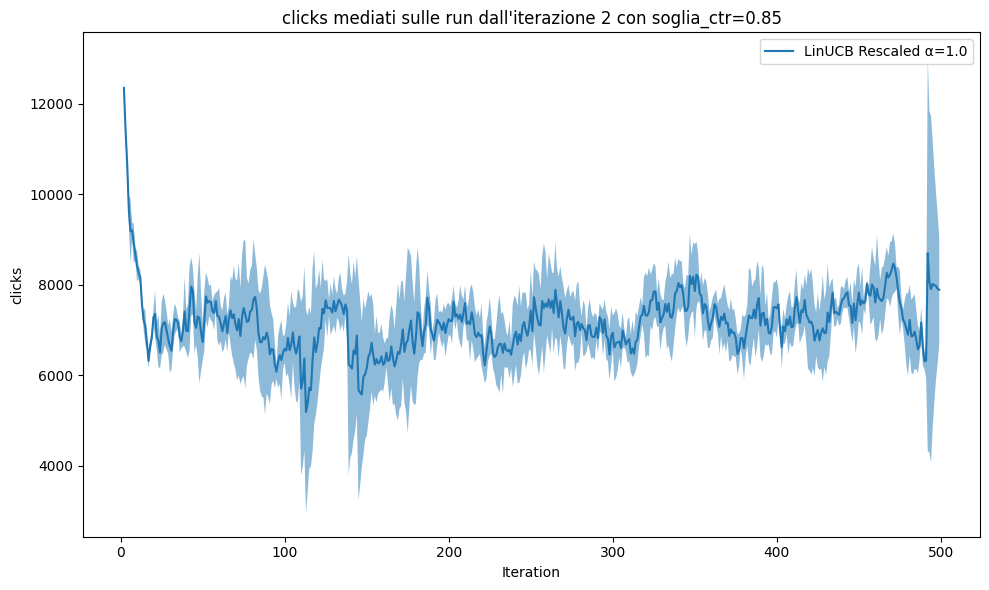

In [8]:
plot_mul_gr_soglia(models, iteration=1, quantity='clicks')

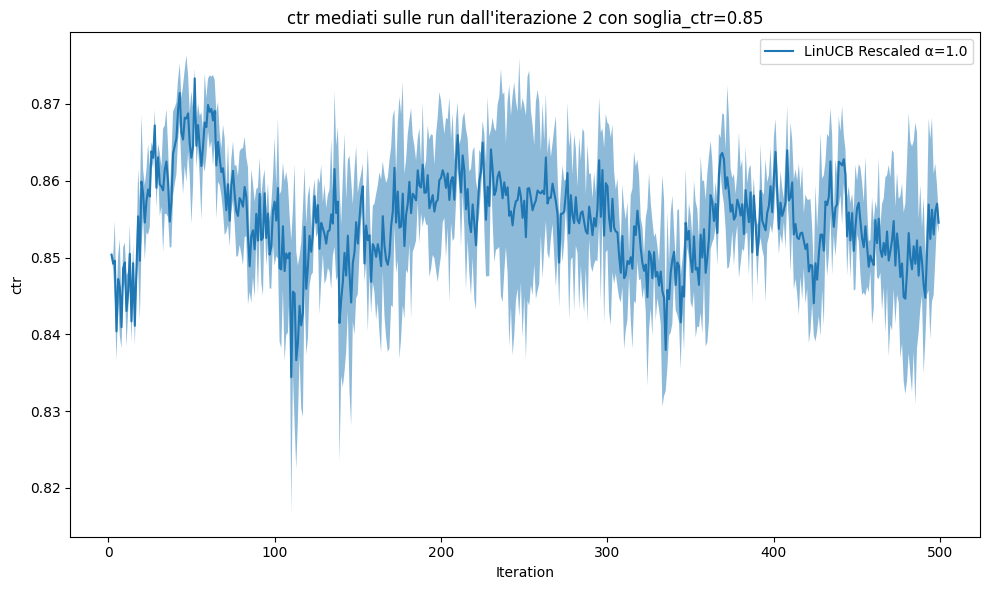

In [9]:
plot_mul_gr_soglia(models, iteration=1, quantity='ctr')

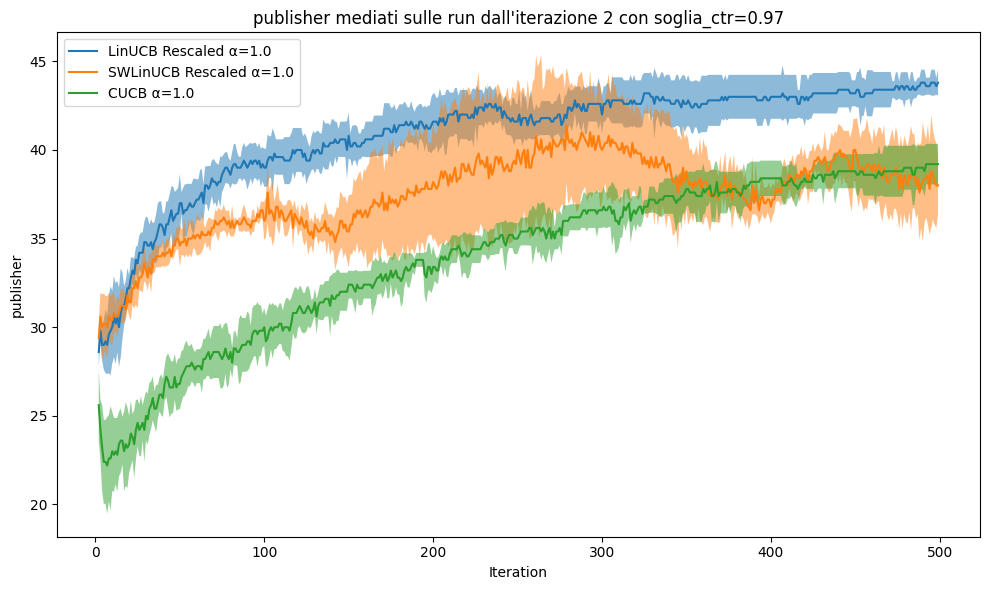

In [12]:
plot_mul_gr_soglia(models, iteration=1, quantity='publisher')

## Dimezzo bid dopo 1/3 delle iterazioni

In [6]:
swlinucb_halftruth_dir_path = '../results/FP_TruthfulHalf_onlynostro_Oracle_sigmoids_swlincub_ctr_0_9_moreruns/'
swlinucb_halftruth_gr_res = group_data_sw(swlinucb_halftruth_dir_path)

In [14]:
linucb_halftruth_dir_path = '../results/FP_TruthfulHalf_onlynostro_Oracle_sigmoids_lincub_ctr_0_9_moreruns/'
linucb_halftruth_gr_res = group_data(linucb_halftruth_dir_path)

In [20]:
cucb_halftruth_dir_path = '../results/FP_TruthfulHalf_onlynostro_Oracle_sigmoids_cucb_ctr_0_9_moreruns/'
cucb_halftruth_gr_res = group_data(cucb_halftruth_dir_path)

In [21]:
models = {
    'SWLinUCB Half-Truthful': swlinucb_halftruth_gr_res,
    'LinUCB Half-Truthful': linucb_halftruth_gr_res,
    'CUCB Half-Truthful': cucb_halftruth_gr_res
}

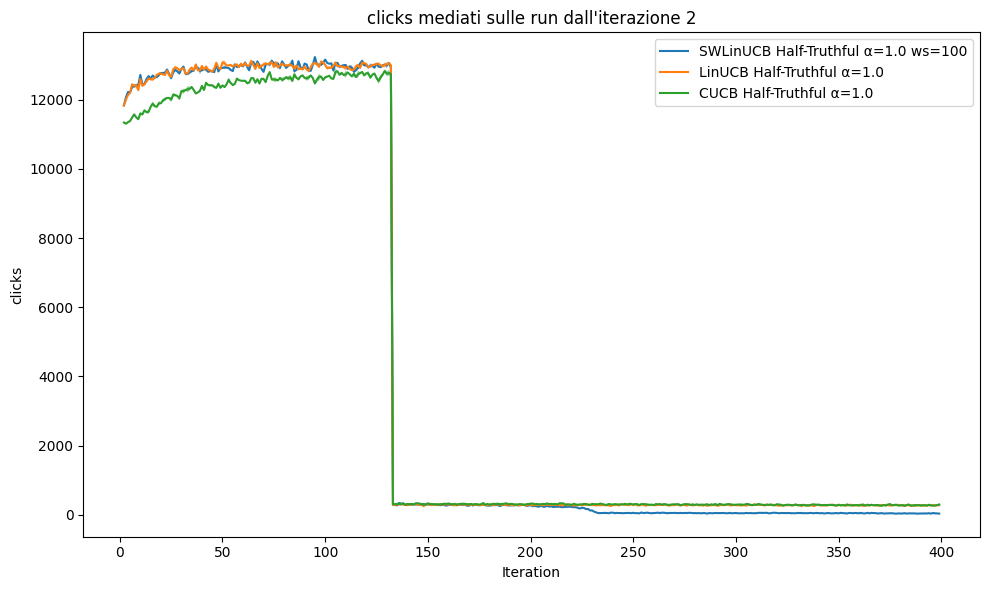

In [22]:
plot_mul_gr(models, iteration=1, quantity='clicks')

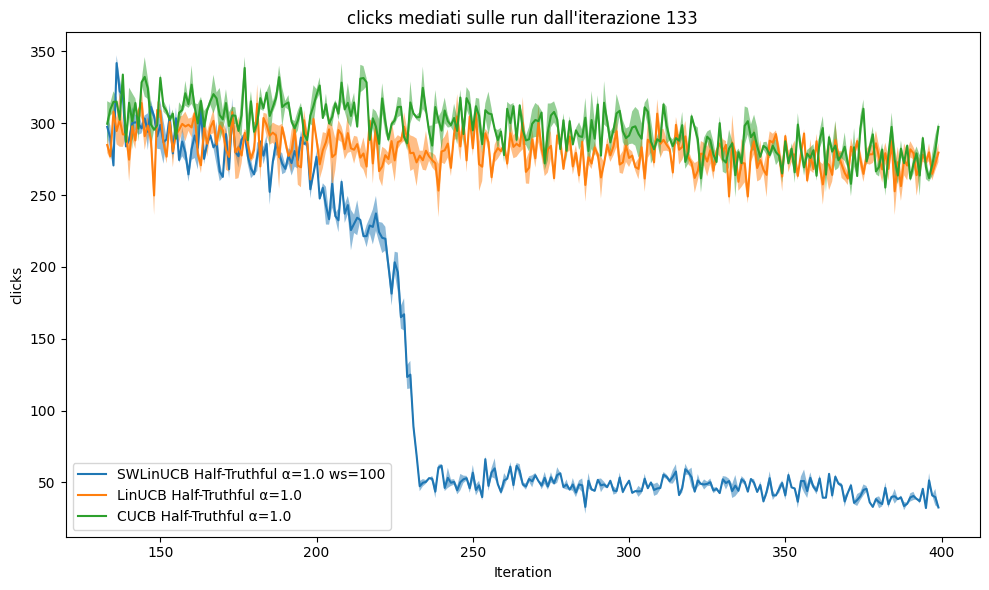

In [23]:
plot_mul_gr(models, iteration=132, quantity='clicks')

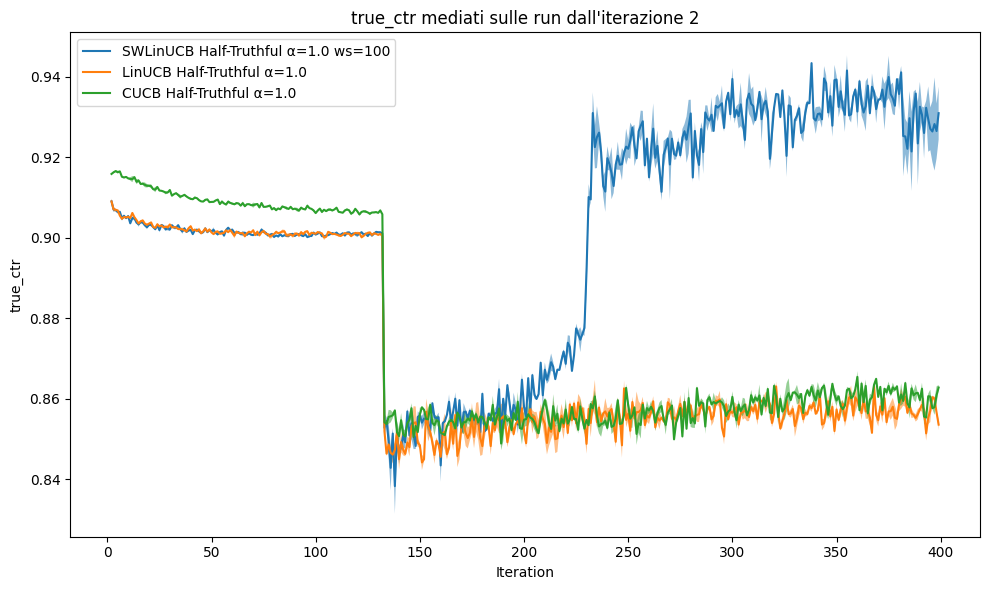

In [24]:
plot_mul_gr(models, iteration=1, quantity='true_ctr')

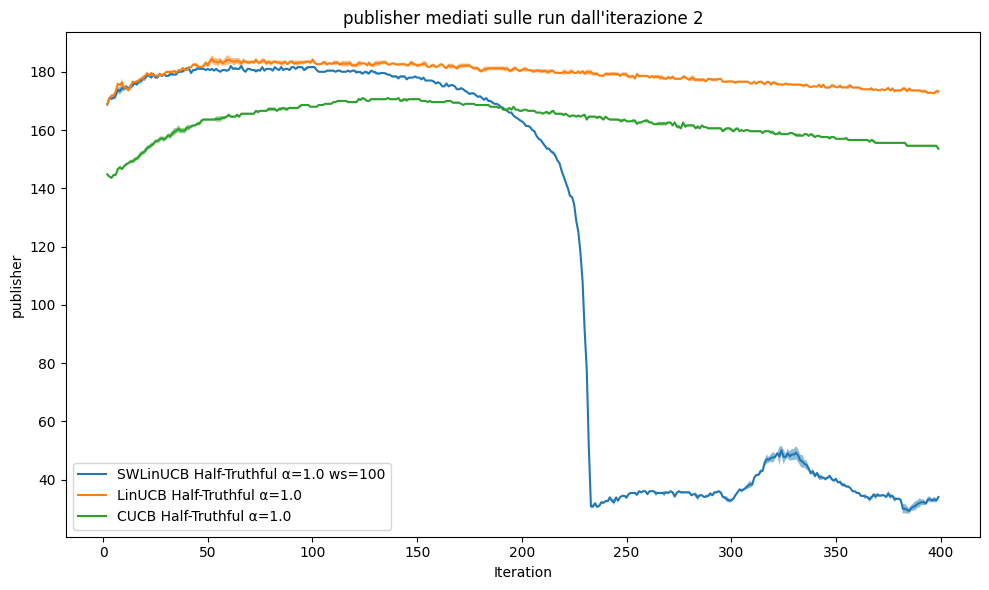

In [25]:
plot_mul_gr(models, iteration=1, quantity='publisher')

## 80% Truthful bidding

In [29]:
swlinucb_truth80_dir_path = '../results/FP_Truthful80_onlynostro_Oracle_sigmoids_swlincub_ctr_0_9/'
swlinucb_truth80_gr_res = group_data_sw(swlinucb_truth80_dir_path)

In [7]:
linucb_truth80_dir_path = '../results/FP_Truthful80_onlynostro_Oracle_sigmoids_lincub_ctr_0_9/'
linucb_truth80_gr_res = group_data(linucb_truth80_dir_path)

In [8]:
swcucb_truth80_dir_path = '../results/FP_Truthful80_onlynostro_Oracle_sigmoids_swcucb_ctr_0_9/'
swcucb_truth80_gr_res = group_data_sw(swcucb_truth80_dir_path)

In [9]:
cucb_truth80_dir_path = '../results/FP_Truthful80_onlynostro_Oracle_sigmoids_cucb_ctr_0_9/'
cucb_truth80_gr_res = group_data(cucb_truth80_dir_path)

In [30]:
models = {
    'SW-LinUCB Truthful 80%': swlinucb_truth80_gr_res,
    'LinUCB Truthful 80%': linucb_truth80_gr_res,
    'SW-CUCB Truthful 80%': swcucb_truth80_gr_res,
    'CUCB Truthful 80%': cucb_truth80_gr_res
}

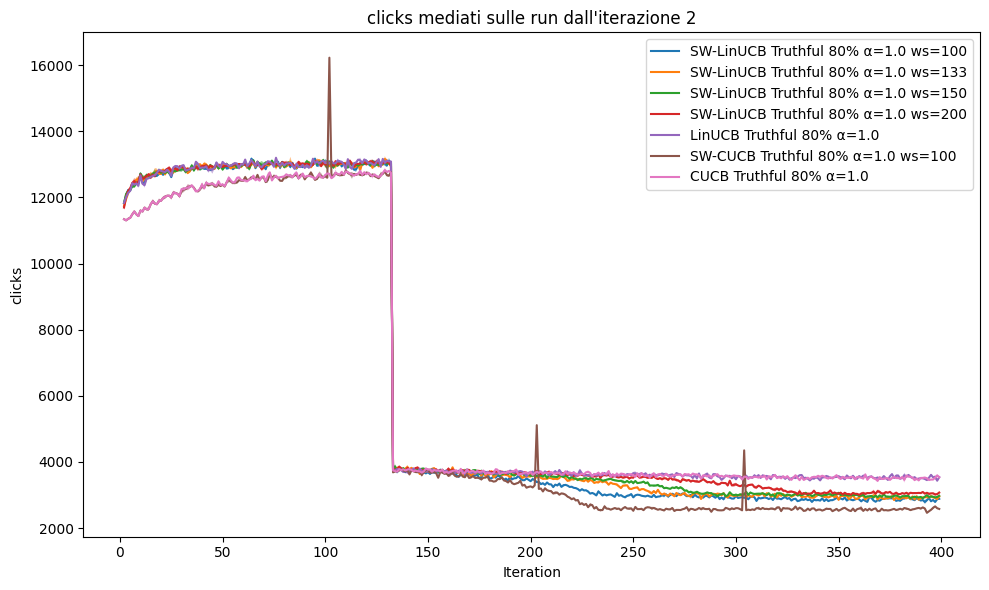

In [31]:
plot_mul_gr(models, iteration=1, quantity='clicks')

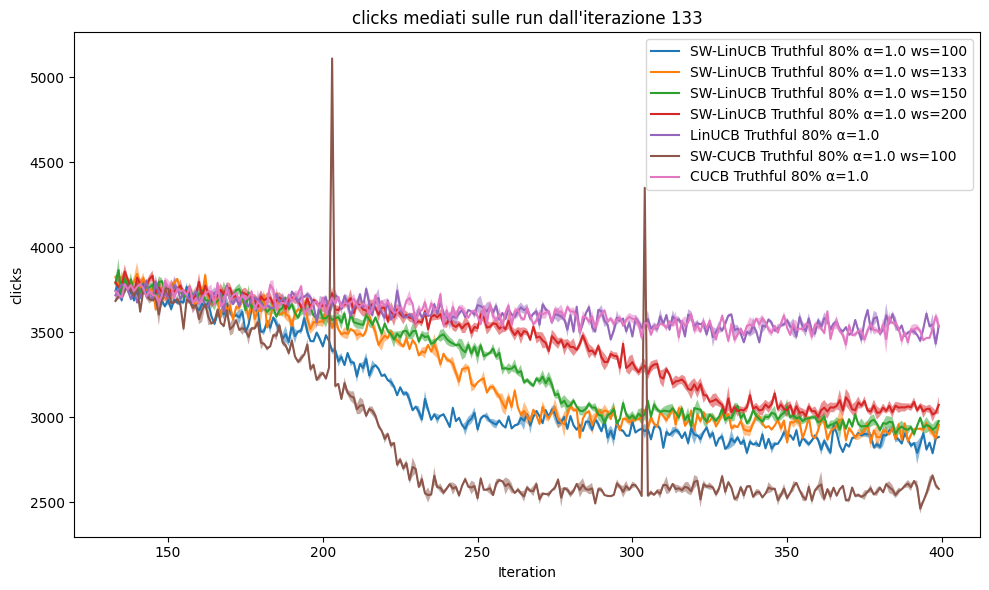

In [32]:
plot_mul_gr(models, iteration=132, quantity='clicks')

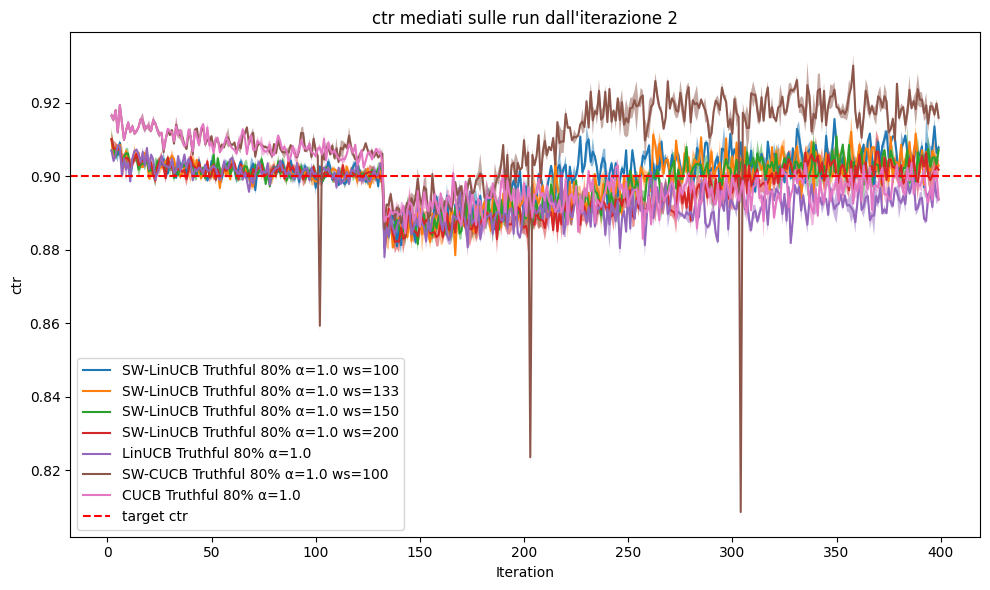

In [33]:
plot_mul_gr(models, iteration=1, quantity='ctr', optimal_quantity=0.9)

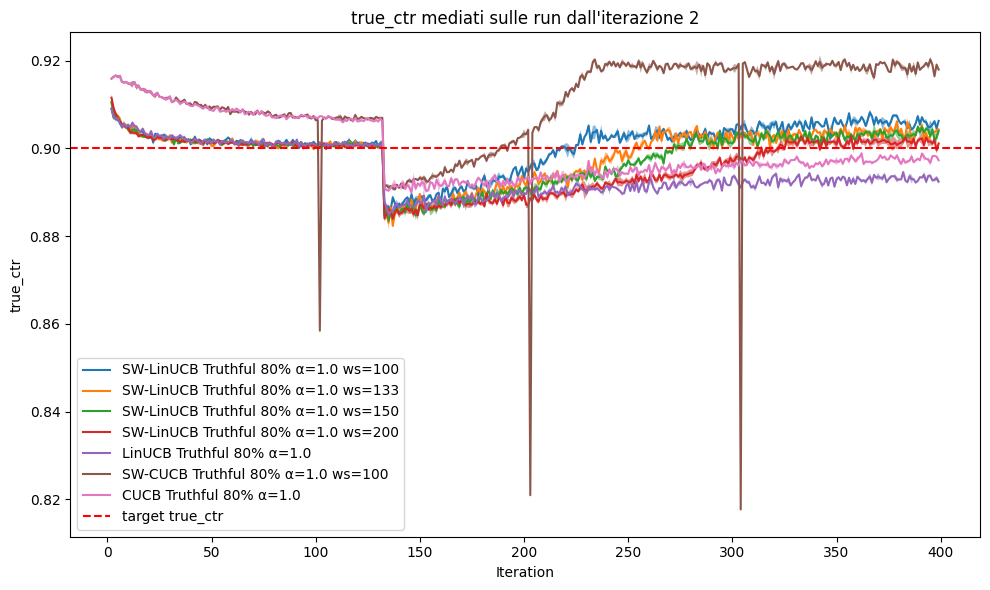

In [34]:
plot_mul_gr(models, iteration=1, quantity='true_ctr', optimal_quantity=0.9)

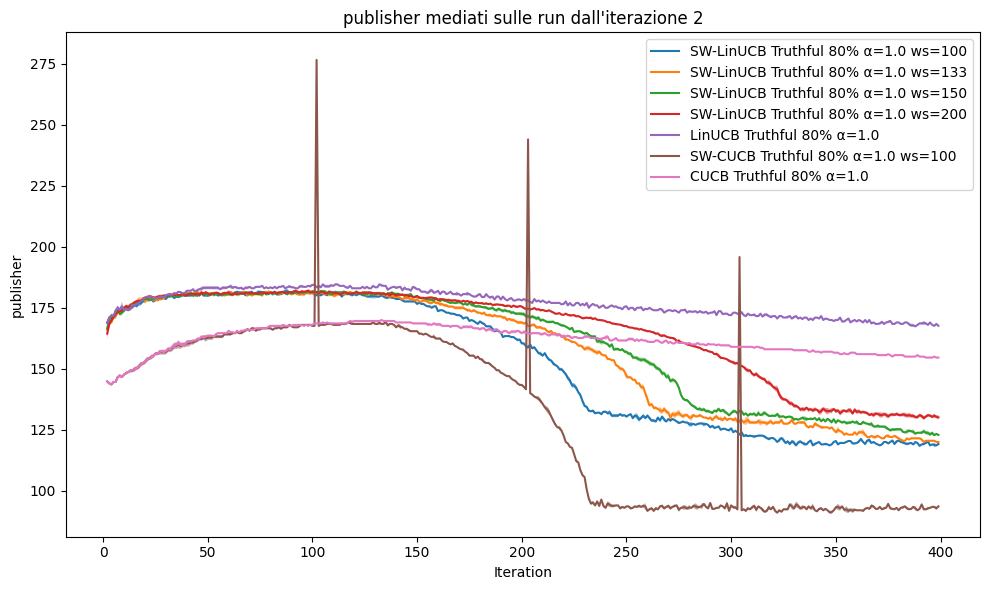

In [35]:
plot_mul_gr(models, iteration=1, quantity='publisher')

# Confronto publisher scelti nell'ultima iterazione tra Truthful e HalfTruthful

In [13]:
def read_all_data(dir_path: str):
    # Load the results
    files_to_read = [file for file in os.listdir(dir_path) if file.endswith('.csv')]
    # SW
    pattern_sw = r'agent_stats_run_(\d+)_ctr_(\d+\.?\d*)_alpha_(\d+\.?\d*)_ws_(\d+)'
    # No SW
    pattern_nosw = r'agent_stats_run_(\d+)_ctr_(\d+\.?\d*)_alpha_(\d+\.?\d*)'
    results = pd.DataFrame()
    if re.search(pattern_sw, files_to_read[0]):
        for file in files_to_read:
            match = re.search(pattern_sw, file)

            ctr_constraint = float(match.group(2))
            alpha = float(match.group(3))
            ws = int(match.group(4))

            curr_results = pd.read_csv(dir_path + file)
            curr_results['ctr_constraint'] = ctr_constraint
            curr_results['alpha'] = alpha
            curr_results['ws'] = ws
            results = pd.concat([results, curr_results])
    elif re.search(pattern_nosw, files_to_read[0]):
        for file in files_to_read:
            match = re.search(pattern_nosw, file)
            
            ctr_constraint = float(match.group(2))
            alpha = float(match.group(3))

            curr_results = pd.read_csv(dir_path + file)
            curr_results['ctr_constraint'] = ctr_constraint
            curr_results['alpha'] = alpha
            results = pd.concat([results, curr_results])
    return results

In [38]:
ctr_constraint = 0.9

In [14]:
linucb_truthful_dir_path = '../results/FP_Truthful_Oracle_sigmoids_linucb_rescaledtextemb_ctr_0_9_10_12_24_nuovipub/'
linucb_truthful = read_all_data(linucb_truthful_dir_path)

In [29]:
linucb_halftruthful_dir_path = '../results/FP_Truthful80_onlynostro_Oracle_sigmoids_lincub_ctr_0_9/'
linucb_halftruthful = read_all_data(linucb_halftruthful_dir_path)

In [15]:
linucb_truthful_lastiter = linucb_truthful[(linucb_truthful['Iteration']==499)&(linucb_truthful['Run']==0)]
linucb_truthful_lastiter_pub_list = linucb_truthful_lastiter['publisher'].unique()

In [16]:
print(f"Number of publishers selected with Truthful bidding: {len(linucb_truthful_lastiter_pub_list)}")

Number of publishers selected with Truthful bidding: 186


In [41]:
linucb_truthful_lastiter_group = linucb_truthful_lastiter.groupby('Iteration').agg({
    'clicks': 'sum', 'impressions': 'sum', 'lost_auctions':'sum', 'mean_bid': 'mean', 'spent': 'sum', 'publisher': 'nunique'}).reset_index()
linucb_truthful_lastiter_group['ctr'] = linucb_truthful_lastiter_group['clicks'] / linucb_truthful_lastiter_group['impressions']
linucb_truthful_lastiter_group['win_rate'] = linucb_truthful_lastiter_group['impressions'] / \
                            (linucb_truthful_lastiter_group['impressions'] + linucb_truthful_lastiter_group['lost_auctions'])

print(f"Clicks = {linucb_truthful_lastiter_group['clicks'].values[0]}")
print(f"Impressions = {linucb_truthful_lastiter_group['impressions'].values[0]}")
print(f"Win rate = {linucb_truthful_lastiter_group['win_rate'].values[0]}")
print(f"CTR = {linucb_truthful_lastiter_group['ctr'].values[0]}")
print(f"% CTR violation = {(np.abs(linucb_truthful_lastiter_group['ctr'].values[0] - ctr_constraint) / ctr_constraint) * 100} %")
print(f"Mean bid = {linucb_truthful_lastiter_group['mean_bid'].values[0]}")
print(f"Spent = {linucb_truthful_lastiter_group['spent'].values[0]}")

Clicks = 13251.0
Impressions = 14716
Win rate = 0.6883390242761589
CTR = 0.9004484914378907
% CTR violation = 0.049832381987857666 %
Mean bid = 0.8871843420690105
Spent = 13246.237825393677


In [30]:
linucb_halftruthful_lastiter = linucb_halftruthful[(linucb_halftruthful['Iteration']==399)&(linucb_halftruthful['Run']==0)]
linucb_halftruthful_lastiter_pub_list = linucb_halftruthful_lastiter['publisher'].unique()

In [31]:
print(f"Number of publishers selected with HalfTruthful bidding: {len(linucb_halftruthful_lastiter_pub_list)}")

Number of publishers selected with HalfTruthful bidding: 168


In [42]:
linucb_halftruthful_lastiter_group = linucb_halftruthful_lastiter.groupby('Iteration').agg({
    'clicks': 'sum', 'impressions': 'sum', 'lost_auctions':'sum', 'mean_bid': 'mean', 'spent': 'sum', 'publisher': 'nunique'}).reset_index()
linucb_halftruthful_lastiter_group['ctr'] = linucb_halftruthful_lastiter_group['clicks'] / linucb_halftruthful_lastiter_group['impressions']
linucb_halftruthful_lastiter_group['win_rate'] = linucb_halftruthful_lastiter_group['impressions'] / \
                            (linucb_halftruthful_lastiter_group['impressions'] + linucb_halftruthful_lastiter_group['lost_auctions'])
print(f"Clicks = {linucb_halftruthful_lastiter_group['clicks'].values[0]}")
print(f"Impressions = {linucb_halftruthful_lastiter_group['impressions'].values[0]}")
print(f"Win rate = {linucb_halftruthful_lastiter_group['win_rate'].values[0]}")
print(f"CTR = {linucb_halftruthful_lastiter_group['ctr'].values[0]}")
print(f"% CTR violation = {(np.abs(linucb_halftruthful_lastiter_group['ctr'].values[0] - ctr_constraint) / ctr_constraint) * 100} %")
print(f"Mean bid = {linucb_halftruthful_lastiter_group['mean_bid'].values[0]}")
print(f"Spent = {linucb_halftruthful_lastiter_group['spent'].values[0]}")

Clicks = 3574.0
Impressions = 4000
Win rate = 0.20913939140437102
CTR = 0.8935
% CTR violation = 0.7222222222222291 %
Mean bid = 0.685319354334236
Spent = 2853.033207511902


In [33]:
common_pub_list = list(set(linucb_truthful_lastiter_pub_list).intersection(linucb_halftruthful_lastiter_pub_list))
print(f"Common selected publishers: {len(common_pub_list)}")

Common selected publishers: 166


### CTR publisher comuni nei due esperimenti

In [34]:
# Truthful
linucb_truthful_lastiter_common = linucb_truthful_lastiter[linucb_truthful_lastiter['publisher'].isin(common_pub_list)]
linucb_truthful_lastiter_common_group = linucb_truthful_lastiter_common.groupby('Iteration').agg({
    'clicks': 'sum', 'impressions': 'sum', 'lost_auctions':'sum', 'mean_bid': 'mean', 'spent': 'sum', 'publisher': 'nunique'}).reset_index()
linucb_truthful_lastiter_common_group['ctr'] = linucb_truthful_lastiter_common_group['clicks'] / linucb_truthful_lastiter_common_group['impressions']
linucb_truthful_lastiter_common_group['win_rate'] = linucb_truthful_lastiter_common_group['impressions'] / \
                            (linucb_truthful_lastiter_common_group['impressions'] + linucb_truthful_lastiter_common_group['lost_auctions'])
print(f"Clicks = {linucb_truthful_lastiter_common_group['clicks'].values[0]}")
print(f"Impressions = {linucb_truthful_lastiter_common_group['impressions'].values[0]}")
print(f"Win rate = {linucb_truthful_lastiter_common_group['win_rate'].values[0]}")
print(f"CTR = {linucb_truthful_lastiter_common_group['ctr'].values[0]}")
print(f"Mean bid = {linucb_truthful_lastiter_common_group['mean_bid'].values[0]}")
print(f"Spent = {linucb_truthful_lastiter_common_group['spent'].values[0]}")
print()
# Half-Truthful
linucb_halftruthful_lastiter_common = linucb_halftruthful_lastiter[linucb_halftruthful_lastiter['publisher'].isin(common_pub_list)]
linucb_halftruthful_lastiter_common_group = linucb_halftruthful_lastiter_common.groupby('Iteration').agg({
    'clicks': 'sum', 'impressions': 'sum', 'lost_auctions':'sum', 'mean_bid': 'mean', 'spent': 'sum', 'publisher': 'nunique'}).reset_index()
linucb_halftruthful_lastiter_common_group['ctr'] = linucb_halftruthful_lastiter_common_group['clicks'] / linucb_halftruthful_lastiter_common_group['impressions']
linucb_halftruthful_lastiter_common_group['win_rate'] = linucb_halftruthful_lastiter_common_group['impressions'] / \
                            (linucb_halftruthful_lastiter_common_group['impressions'] + linucb_halftruthful_lastiter_common_group['lost_auctions'])
print(f"Clicks = {linucb_halftruthful_lastiter_common_group['clicks'].values[0]}")
print(f"Impressions = {linucb_halftruthful_lastiter_common_group['impressions'].values[0]}")
print(f"Win rate = {linucb_halftruthful_lastiter_common_group['win_rate'].values[0]}")
print(f"CTR = {linucb_halftruthful_lastiter_common_group['ctr'].values[0]}")
print(f"Mean bid = {linucb_halftruthful_lastiter_common_group['mean_bid'].values[0]}")
print(f"Spent = {linucb_halftruthful_lastiter_common_group['spent'].values[0]}")

Clicks = 12442.0
Impressions = 13717
Win rate = 0.7202415332108165
CTR = 0.9070496464241452
Mean bid = 0.8954824460558144
Spent = 12421.78341960907

Clicks = 3560.0
Impressions = 3983
Win rate = 0.21067386015021686
CTR = 0.8937986442380116
Mean bid = 0.6861386920158152
Spent = 2842.1346120357516


### Sliding-window

In [18]:
swlinucb_halftruthful_dir_path = '../results/FP_Truthful80_onlynostro_Oracle_sigmoids_swlincub_ctr_0_9/'
swlinucb_halftruthful = read_all_data(swlinucb_halftruthful_dir_path)

In [44]:
swlinucb_halftruthful_lastiter = swlinucb_halftruthful[(swlinucb_halftruthful['Iteration']==399)&
                                                       (swlinucb_halftruthful['Run']==0)&
                                                       (swlinucb_halftruthful['ws']==100)&
                                                       (swlinucb_halftruthful['ctr_constraint']==0.9)]
swlinucb_halftruthful_lastiter_pub_list = swlinucb_halftruthful_lastiter['publisher'].unique()
swlinucb_halftruthful_lastiter_group = swlinucb_halftruthful_lastiter.groupby('Iteration').agg({
    'clicks': 'sum', 'impressions': 'sum', 'lost_auctions':'sum', 'mean_bid': 'mean', 'spent': 'sum', 'publisher': 'nunique'}).reset_index()
swlinucb_halftruthful_lastiter_group['ctr'] = swlinucb_halftruthful_lastiter_group['clicks'] / swlinucb_halftruthful_lastiter_group['impressions']
swlinucb_halftruthful_lastiter_group['win_rate'] = swlinucb_halftruthful_lastiter_group['impressions'] / \
                            (swlinucb_halftruthful_lastiter_group['impressions'] + swlinucb_halftruthful_lastiter_group['lost_auctions'])

print(f"Clicks = {swlinucb_halftruthful_lastiter_group['clicks'].values[0]}")
print(f"Impressions = {swlinucb_halftruthful_lastiter_group['impressions'].values[0]}")
print(f"Win rate = {swlinucb_halftruthful_lastiter_group['win_rate'].values[0]}")
print(f"CTR = {swlinucb_halftruthful_lastiter_group['ctr'].values[0]}")
print(f"% CTR violation = {(np.abs(swlinucb_halftruthful_lastiter_group['ctr'].values[0] - ctr_constraint) / ctr_constraint) * 100} %")
print(f"Mean bid = {swlinucb_halftruthful_lastiter_group['mean_bid'].values[0]}")
print(f"Spent = {swlinucb_halftruthful_lastiter_group['spent'].values[0]}")

Clicks = 2878.0
Impressions = 3174
Win rate = 0.231712658782304
CTR = 0.9067422810333964
% CTR violation = 0.7491423370440398 %
Mean bid = 0.7050759550310755
Spent = 2302.5084088325502


In [20]:
print(f"Number of publishers selected with HalfTruthful bidding from SW: {len(swlinucb_halftruthful_lastiter_pub_list)}")

Number of publishers selected with HalfTruthful bidding from SW: 120


In [21]:
common_pub_list = list(set(linucb_truthful_lastiter_pub_list).intersection(swlinucb_halftruthful_lastiter_pub_list))
print(f"Common selected publishers: {len(common_pub_list)}")

Common selected publishers: 119


In [43]:
swlinucb_halftruthful_lastiter_common = swlinucb_halftruthful_lastiter[swlinucb_halftruthful_lastiter['publisher'].isin(common_pub_list)]
swlinucb_halftruthful_lastiter_common_group = swlinucb_halftruthful_lastiter_common.groupby('Iteration').agg({
    'clicks': 'sum', 'impressions': 'sum', 'lost_auctions':'sum', 'mean_bid': 'mean', 'spent': 'sum', 'publisher': 'nunique'}).reset_index()
swlinucb_halftruthful_lastiter_common_group['ctr'] = swlinucb_halftruthful_lastiter_common_group['clicks'] / swlinucb_halftruthful_lastiter_common_group['impressions']
swlinucb_halftruthful_lastiter_common_group['win_rate'] = swlinucb_halftruthful_lastiter_common_group['impressions'] / \
                            (swlinucb_halftruthful_lastiter_common_group['impressions'] + swlinucb_halftruthful_lastiter_common_group['lost_auctions'])
print(f"Clicks = {swlinucb_halftruthful_lastiter_common_group['clicks'].values[0]}")
print(f"Impressions = {swlinucb_halftruthful_lastiter_common_group['impressions'].values[0]}")
print(f"Win rate = {swlinucb_halftruthful_lastiter_common_group['win_rate'].values[0]}")
print(f"CTR = {swlinucb_halftruthful_lastiter_common_group['ctr'].values[0]}")
print(f"% CTR violation = {(np.abs(swlinucb_halftruthful_lastiter_common_group['ctr'].values[0] - ctr_constraint) / ctr_constraint) * 100} %")
print(f"Mean bid = {swlinucb_halftruthful_lastiter_common_group['mean_bid'].values[0]}")
print(f"Spent = {swlinucb_halftruthful_lastiter_common_group['spent'].values[0]}")

Clicks = 2864.0
Impressions = 3159
Win rate = 0.23260437375745527
CTR = 0.9066160177271289
% CTR violation = 0.7351130807920924 %
Mean bid = 0.7055596725991711
Spent = 2292.795705366135


# Other plots

In [21]:
def get_linucb_predictions(
        result_dir_path: str, 
        publisher_embeddings: dict,
        theta_click_path: str = 'linucb_theta_click_run_0_ctr_0.9_alpha_1.pkl',
        theta_impression_path: str = 'linucb_theta_impressions_run_0_ctr_0.9_alpha_1.pkl',
        is_log_predictions: bool = False
) -> pd.DataFrame:
    linucb_theta_click = pickle.load(open(f'{result_dir_path}{theta_click_path}', 'rb'))
    linucb_theta_impression = pickle.load(open(f'{result_dir_path}{theta_impression_path}', 'rb'))
    linucb_predictions = []
    for pub, emb in publisher_embeddings.items():
        if is_log_predictions:
            click_prediction = np.exp(np.dot(emb, linucb_theta_click))
            impression_prediction = np.exp(np.dot(emb, linucb_theta_impression))
        else:
            click_prediction = np.dot(emb, linucb_theta_click)
            impression_prediction = np.dot(emb, linucb_theta_impression)
        curr_pred = {'publisher': pub, 'clicks': click_prediction, 'impressions': impression_prediction}
        linucb_predictions.append(curr_pred)
    linucb_predictions_df = pd.DataFrame(linucb_predictions)
    linucb_predictions_df['ctr'] = linucb_predictions_df['clicks'] / linucb_predictions_df['impressions']
    return linucb_predictions_df

In [22]:
def read_all_data(dir_path: str):
    # Load the results
    files_to_read = [file for file in os.listdir(dir_path) if file.endswith('.csv')]
    pattern = r'agent_stats_run_(\d+)_ctr_(\d+\.?\d*)_alpha_(\d+\.?\d*)'
    files_per_alpha = {}
    for file in files_to_read:
        match = re.search(pattern, file)
        if match:
            alpha = float(match.group(3))
            if alpha not in files_per_alpha:
                files_per_alpha[alpha] = [file]
            else:
                files_per_alpha[alpha].append(file)
    # Load the results
    results = pd.DataFrame()
    for alpha, files in files_per_alpha.items():
        for file in files:
            curr_results = pd.read_csv(dir_path + file)
            curr_results['alpha'] = alpha
            results = pd.concat([results, curr_results])
    return results

In [23]:
def get_pub_stats(results_df, run=0):
    stats_results = results_df[results_df['Run']==run].groupby(['alpha', 'Run', 'publisher']) \
        .size().reset_index(name='counts') \
        .sort_values(by='counts', ascending=False)
    return stats_results

In [24]:
pub_embeddings_path = '../src/publisher_embedding/data/embeddings_to_pick/sites_embeddings_red_70.pkl'
pub_embeddings = pickle.load(open(pub_embeddings_path, 'rb'))

In [25]:
linucb_predictions = get_linucb_predictions(
    result_dir_path=linucb_dir_path,
    publisher_embeddings=pub_embeddings,
    theta_click_path='linucb_theta_click_run_0_ctr_0.9_alpha_1.pkl',
    theta_impression_path='linucb_theta_impressions_run_0_ctr_0.9_alpha_1.pkl'
)
linucb_all_data = read_all_data(linucb_dir_path)
linucb_pub_counts = get_pub_stats(linucb_all_data)
linucb_pred_counts = pd.merge(
    linucb_predictions,
    linucb_pub_counts,
    on='publisher',
    how='inner'
)

In [26]:
pub_emb_rescaled = pickle.load(open('../src/publisher_embedding/data/embeddings_to_pick/sites_embeddings_red_70_scaled.pkl', 'rb'))
linucb_rescaled_predictions = get_linucb_predictions(
    result_dir_path=linucb_rescaled_dir_path,
    publisher_embeddings=pub_emb_rescaled,
    theta_click_path='linucb_theta_click_run_0_ctr_0.9_alpha_1.pkl',
    theta_impression_path='linucb_theta_impressions_run_0_ctr_0.9_alpha_1.pkl'
)
linucb_rescaled_all_data = read_all_data(linucb_rescaled_dir_path)
linucb_rescaled_pub_counts = get_pub_stats(linucb_rescaled_all_data)
linucb_rescaled_pred_counts = pd.merge(
    linucb_rescaled_predictions,
    linucb_rescaled_pub_counts,
    on='publisher',
    how='inner'
)

In [27]:
cucb_click_path = f'{cucb_dir_path}cucb_est_click_run_0_ctr_0.9_alpha_1.pkl'
cucb_impression_path = f'{cucb_dir_path}cucb_est_impressions_run_0_ctr_0.9_alpha_1.pkl'
cucb_click = pickle.load(open(cucb_click_path, 'rb'))
cucb_impression = pickle.load(open(cucb_impression_path, 'rb'))

cucb_click_df = pd.DataFrame(list(cucb_click.items()), columns=['publisher', 'clicks'])
cucb_impression_df = pd.DataFrame(list(cucb_impression.items()), columns=['publisher', 'impressions'])

cucb_predictions_df = pd.merge(cucb_click_df, cucb_impression_df, on='publisher')
cucb_predictions_df['ctr'] = cucb_predictions_df['clicks'] / cucb_predictions_df['impressions']

cucb_all_data = read_all_data(cucb_dir_path)
cucb_pub_counts = get_pub_stats(cucb_all_data)
cucb_pred_counts = pd.merge(
    cucb_predictions_df,
    cucb_pub_counts,
    on='publisher',
    how='inner'
)

In [28]:
# Order predictions from the publisher with the highest cucb prediction to the lowest
cucb_pred_counts = cucb_pred_counts.sort_values(by='clicks', ascending=False)
pub_ordered = cucb_pred_counts['publisher'].values

linucb_pred_counts = linucb_pred_counts[linucb_pred_counts['publisher'].isin(pub_ordered)]
linucb_pred_counts['publisher'] = pd.Categorical(linucb_pred_counts['publisher'], categories=pub_ordered, ordered=True)
linucb_pred_counts = linucb_pred_counts.sort_values(by='publisher')

linucb_rescaled_pred_counts = linucb_rescaled_pred_counts[linucb_rescaled_pred_counts['publisher'].isin(pub_ordered)]
linucb_rescaled_pred_counts['publisher'] = pd.Categorical(linucb_rescaled_pred_counts['publisher'], categories=pub_ordered, ordered=True)
linucb_rescaled_pred_counts = linucb_rescaled_pred_counts.sort_values(by='publisher')

In [29]:
def plot_pred_counts(linucb_pred_counts, cucb_pred_counts, estimated_quantity='clicks', linucb_label='LinUCB with rescaled embeddings'):
    plt.figure(figsize=(25, 10.5))

    # Scatter plot per CUCB con marker colorati
    plt.scatter(
        cucb_pred_counts['publisher'],
        cucb_pred_counts[estimated_quantity],
        c=cucb_pred_counts['counts'],
        cmap='viridis',
        marker='o',
        label='CUCB'
    )
    # Linea che unisce i punti CUCB
    plt.plot(
        cucb_pred_counts['publisher'].to_numpy(),
        cucb_pred_counts[estimated_quantity].to_numpy(),
        color='blue'
    )

    # Scatter plot per LinUCB con marker colorati
    plt.scatter(
        linucb_pred_counts['publisher'],
        linucb_pred_counts[estimated_quantity],
        c=linucb_pred_counts['counts'],
        cmap='plasma',
        marker='v',
        label=linucb_label
    )
    # Linea che unisce i punti LinUCB
    plt.plot(
        linucb_pred_counts['publisher'].to_numpy(),
        linucb_pred_counts[estimated_quantity].to_numpy(),
        color='orange'
    )

    plt.colorbar(label='# of iterations a publisher is selected')
    plt.gca().set_xticklabels([])
    plt.xlabel('Publisher')
    plt.ylabel(estimated_quantity)
    plt.legend()
    plt.show()

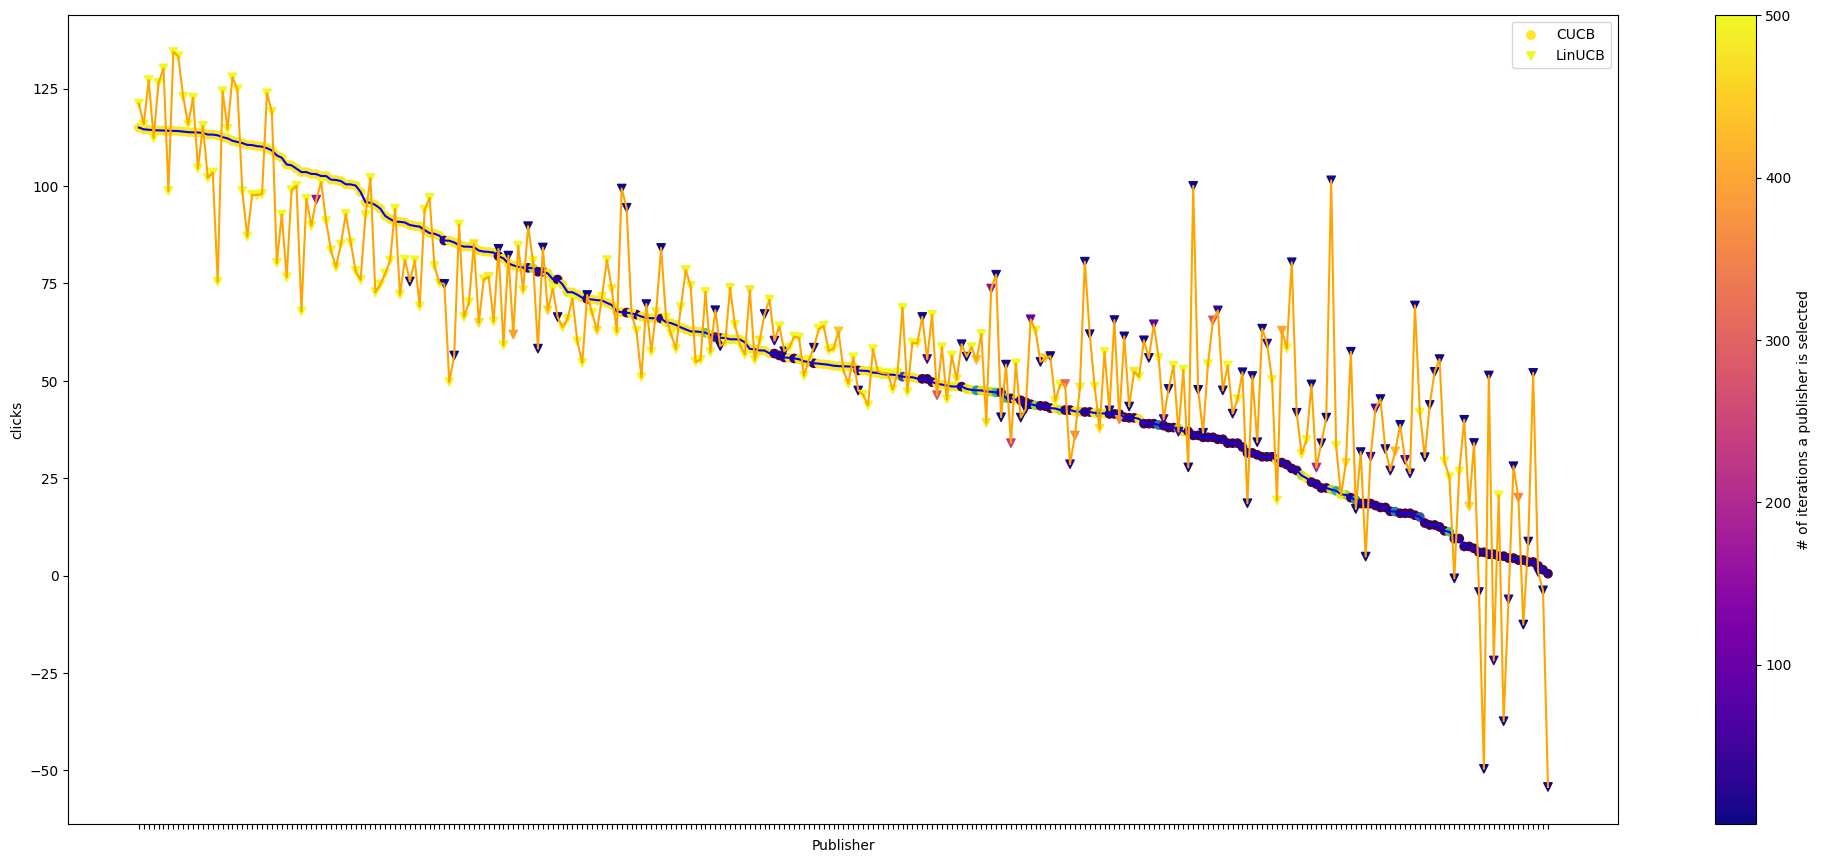

In [30]:
plot_pred_counts(linucb_pred_counts, cucb_pred_counts, linucb_label='LinUCB')

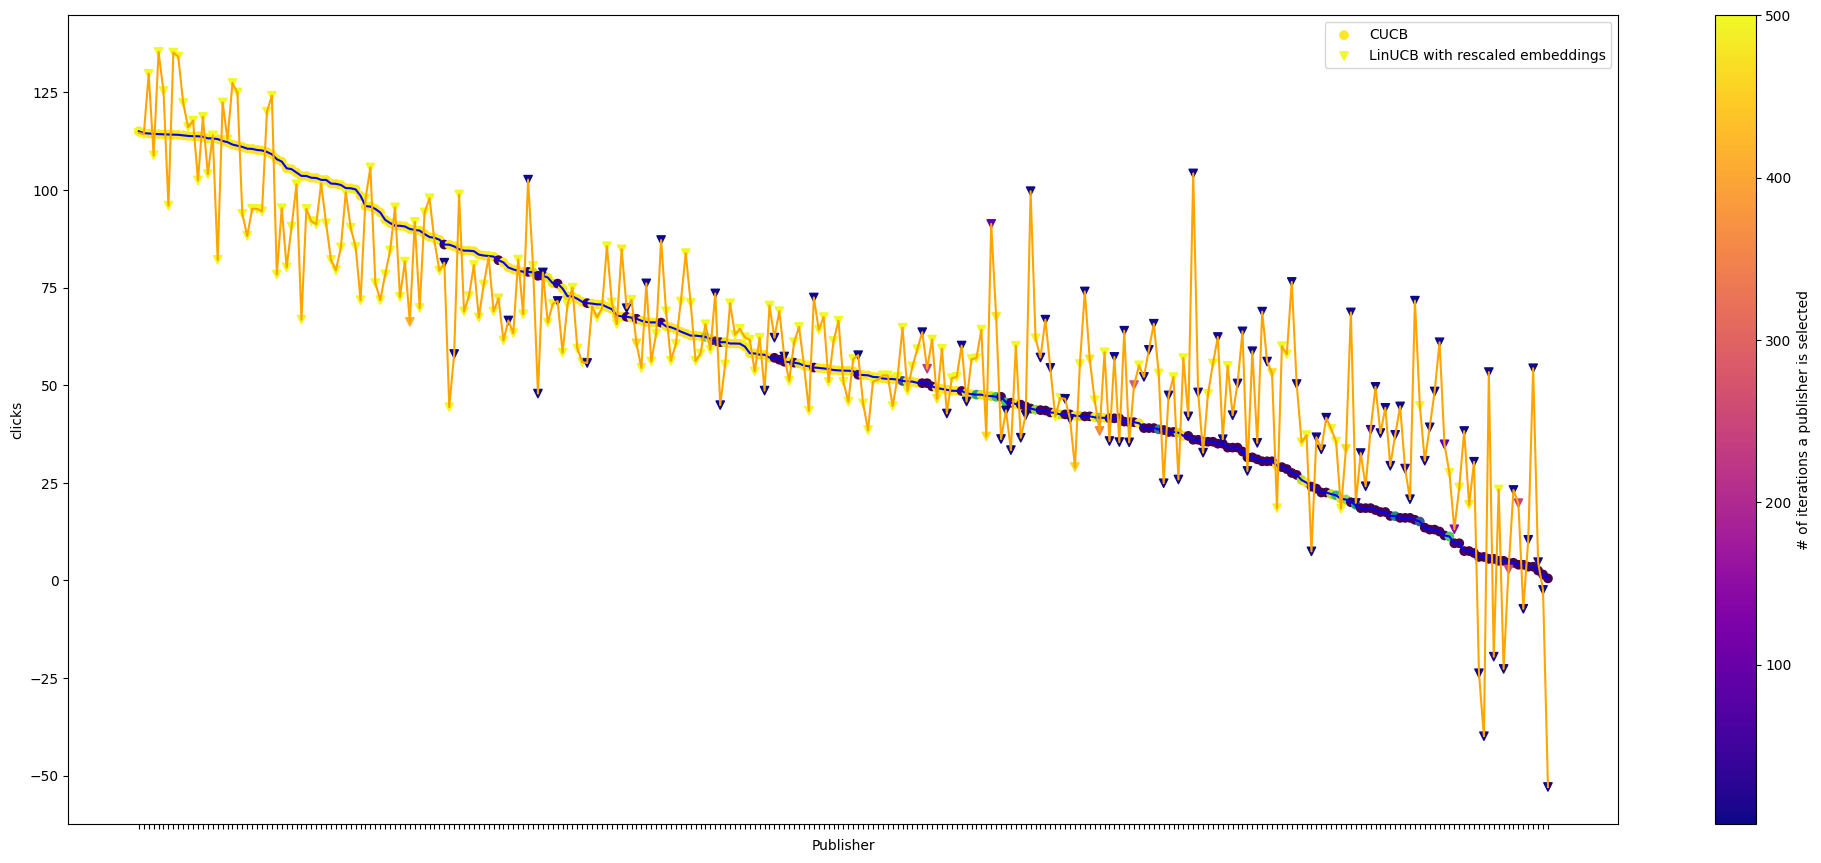

In [31]:
plot_pred_counts(linucb_rescaled_pred_counts, cucb_pred_counts, linucb_label='LinUCB with rescaled embeddings')

In [27]:
def plot_predictions(linucb_predictions, cucb_predictions, linucb_log_predictions=None, estimated_quantity='clicks'):
    # Order cucb predictions from the highest to the lowest
    cucb_predictions = cucb_predictions.sort_values(by=estimated_quantity, ascending=False)
    # Order linucb predictions from the publisher with the highest cucb prediction to the lowest    
    pub_ordered = cucb_predictions['publisher'].values
    linucb_predictions = linucb_predictions[linucb_predictions['publisher'].isin(pub_ordered)]
    linucb_predictions['publisher'] = pd.Categorical(linucb_predictions['publisher'], categories=pub_ordered, ordered=True)
    linucb_predictions = linucb_predictions.sort_values(by='publisher')
    if linucb_log_predictions is not None:
        linucb_log_predictions = linucb_log_predictions[linucb_log_predictions['publisher'].isin(pub_ordered)]
        linucb_log_predictions['publisher'] = pd.Categorical(linucb_log_predictions['publisher'], categories=pub_ordered, ordered=True)
        linucb_log_predictions = linucb_log_predictions.sort_values(by='publisher')
    plt.figure(figsize=(25, 10.5))
    plt.plot(cucb_predictions['publisher'].to_numpy(), cucb_predictions[estimated_quantity].to_numpy(), label='CUCB')
    plt.plot(cucb_predictions['publisher'].to_numpy(), linucb_predictions[estimated_quantity].to_numpy(), label='LinUCB')
    if linucb_log_predictions is not None:
        plt.plot(cucb_predictions['publisher'].to_numpy(), linucb_log_predictions[estimated_quantity].to_numpy(), label='LinUCB LogPred')
    plt.axhline(y=0, color='black', linestyle='--')
    if estimated_quantity == 'ctr':
        plt.axhline(y=1, color='black', linestyle='--')
    plt.xlabel('Publisher')
    plt.ylabel(f'Estimated {estimated_quantity}')
    plt.gca().set_xticklabels([])
    plt.legend()
    plt.show()

/tmp/ipykernel_207015/1857399742.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  linucb_predictions['publisher'] = pd.Categorical(linucb_predictions['publisher'], categories=pub_ordered, ordered=True)
/tmp/ipykernel_207015/1857399742.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  linucb_log_predictions['publisher'] = pd.Categorical(linucb_log_predictions['publisher'], categories=pub_ordered, ordered=True)


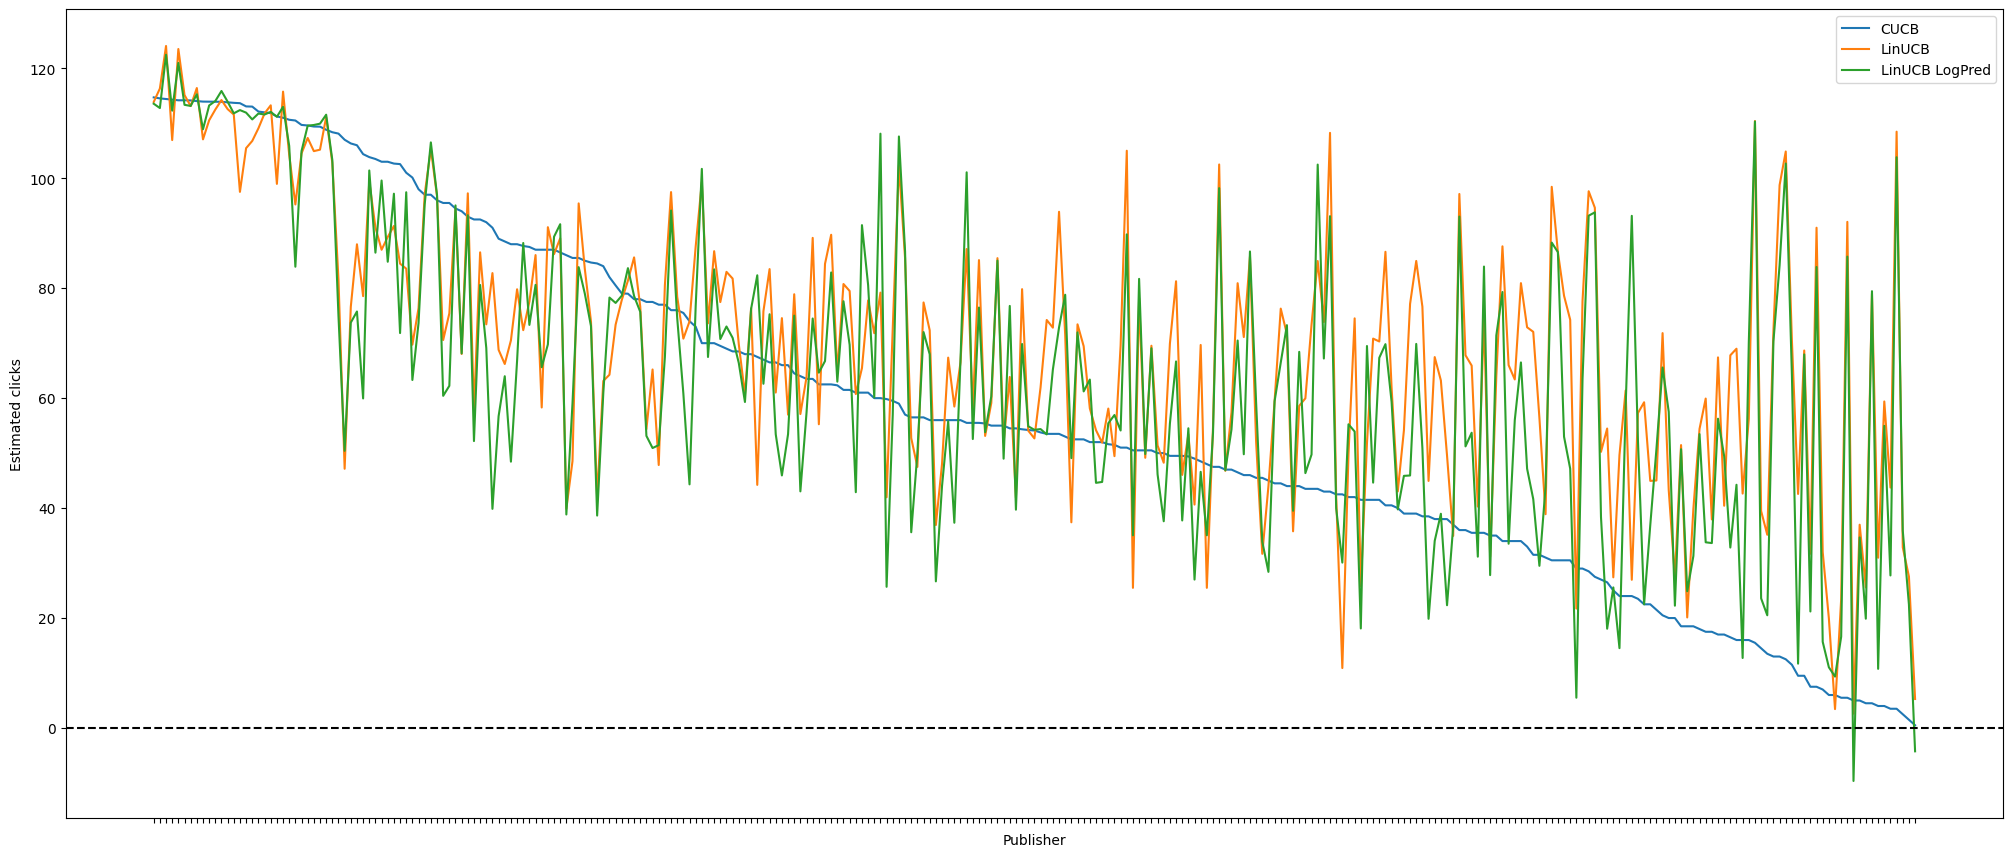

In [29]:
plot_predictions(linucb_predictions, cucb_predictions_df, linucb_rescaled_predictions, estimated_quantity='clicks')

In [33]:
linucb_all_res = read_all_data(linucb_dir_path)

In [38]:
linucb_liscio_stats = get_pub_stats(linucb_all_res, run=6)

In [60]:
cucb_all_res = read_all_data(cucb_newagent_dir_path)

In [ ]:
cucb_li_stats = get_pub_stats(cucb_all_res)

,alpha,Run,publisher,counts
200,1.0,0,motoservices.com,498
53,1.0,0,coches.net,498
107,1.0,0,formulapassion.it,498
270,1.0,0,turbo.fr,497
195,1.0,0,moniteurautomobile.be,497
164,1.0,0,leblogauto.com,496
146,1.0,0,it.motor1.com,496
199,1.0,0,motorsport.nextgen-auto.com,495
197,1.0,0,moto.it,494
198,1.0,0,motociclismo.it,494


In [64]:
linucb_rescaled_all_res = read_all_data(linucb_rescaled_dir_path)

linucb_rescaled_stats = get_pub_stats(linucb_rescaled_all_res)
linucb_rescaled_stats.head(20)

,alpha,Run,publisher,counts
23,1.0,0,motoservices.com,498
18,1.0,0,m.olx.pl,498
19,1.0,0,moniteurautomobile.be,498
14,1.0,0,it.motor1.com,498
20,1.0,0,moto.it,498
21,1.0,0,motociclismo.it,498
16,1.0,0,leblogauto.com,498
28,1.0,0,turbo.fr,498
3,1.0,0,borsaitaliana.it,498
11,1.0,0,formulapassion.it,495
